# Images

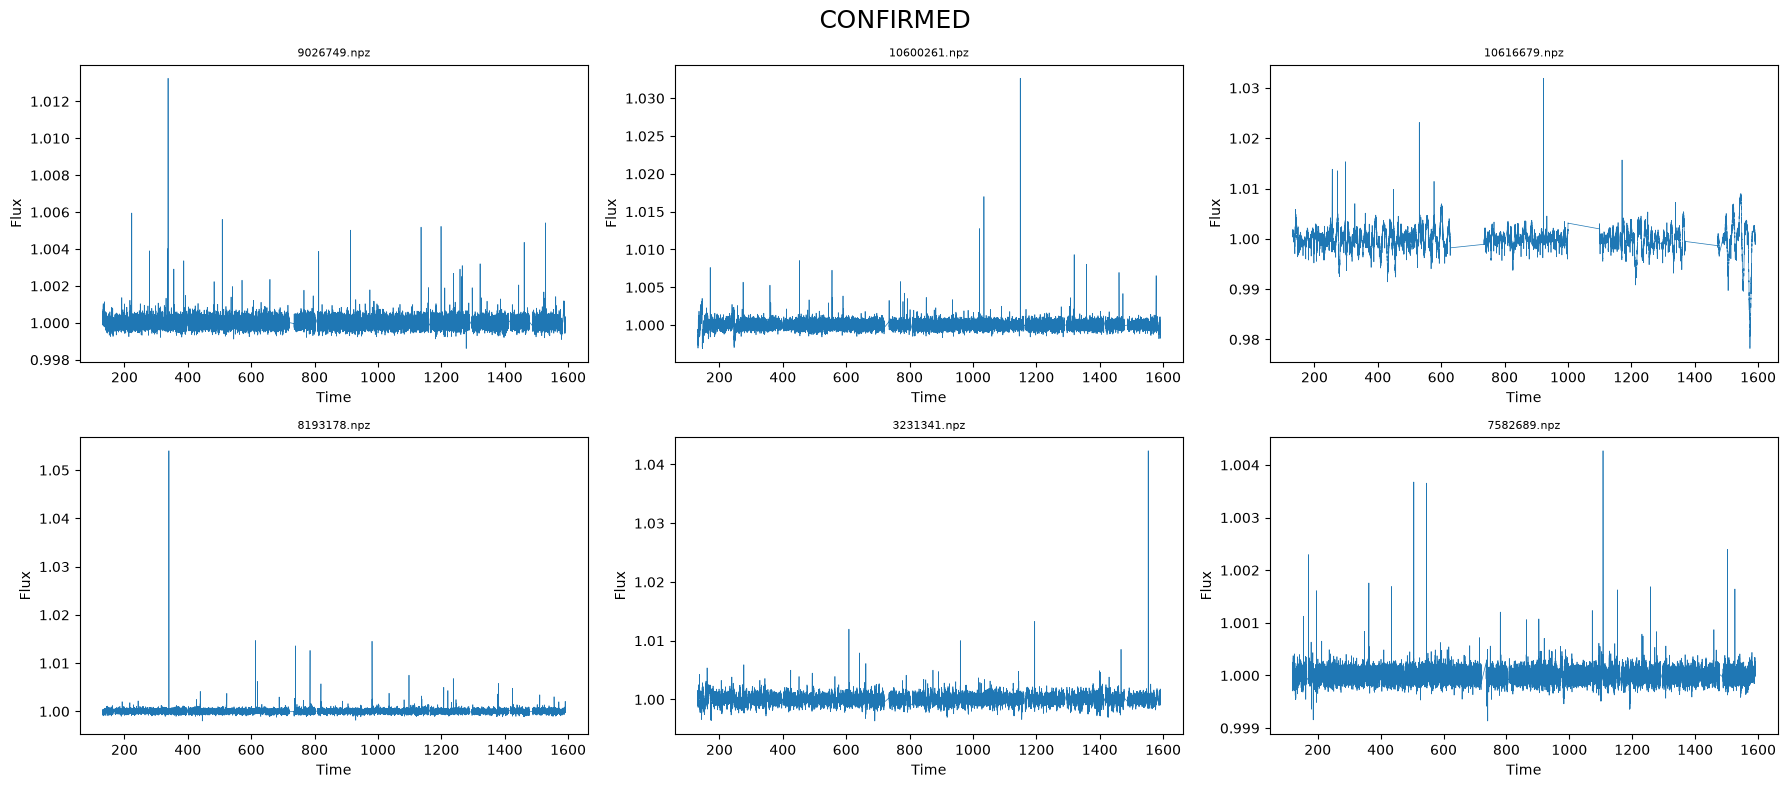

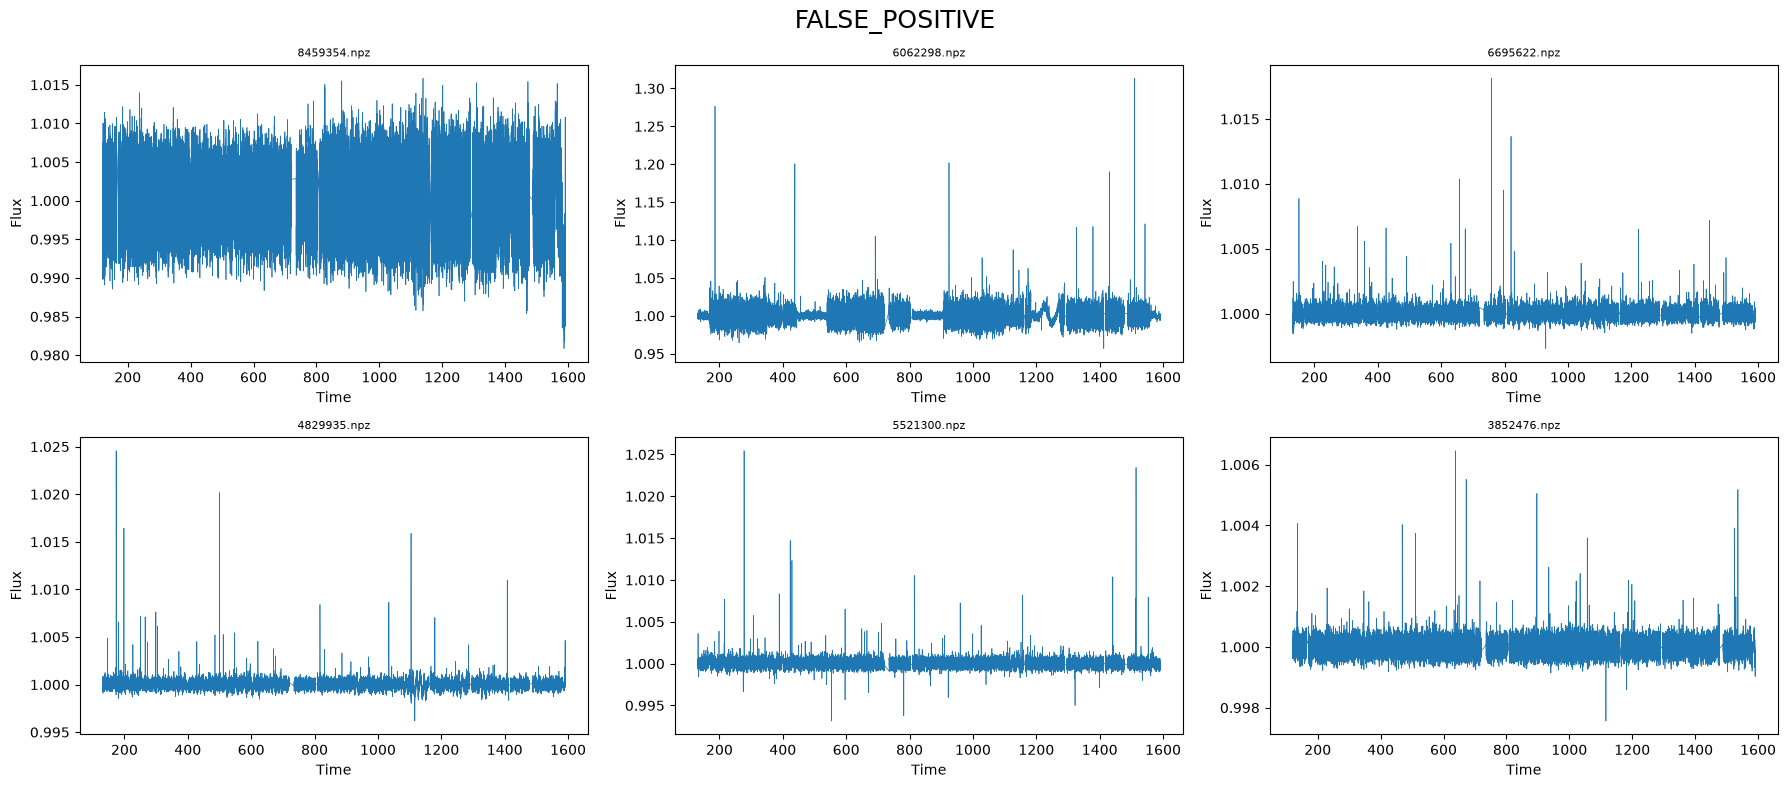

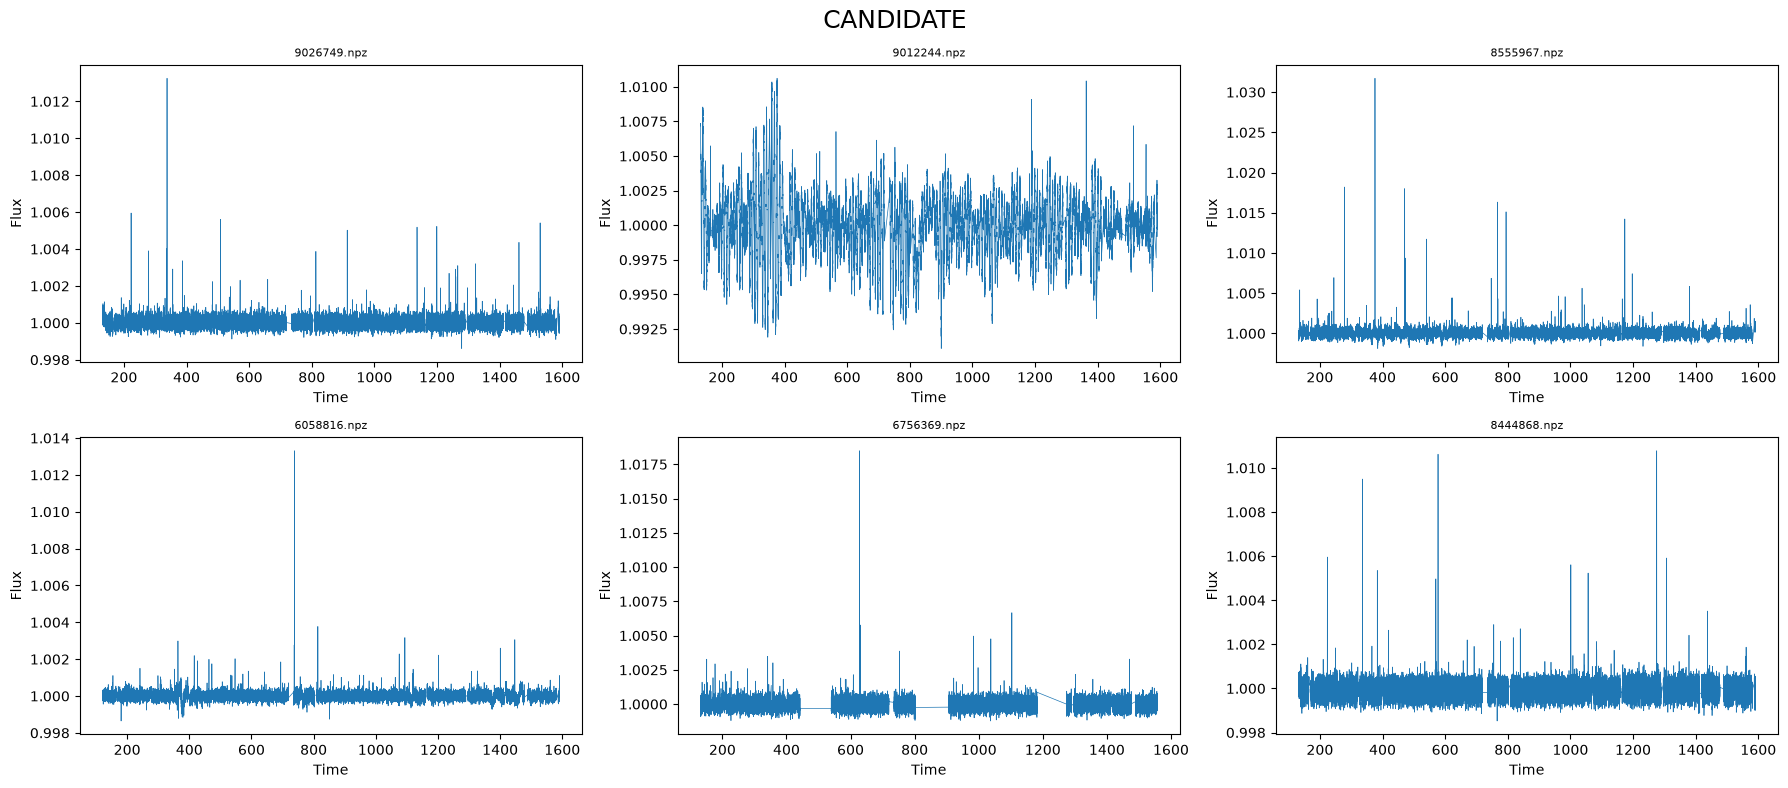

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Dataset root
DATASET_DIR = r"D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset"

classes = [
    "CONFIRMED",
    "FALSE_POSITIVE",
    "CANDIDATE"
]

N_SAMPLES = 6

for cls in classes:

    folder = os.path.join(DATASET_DIR, cls)

    files = [f for f in os.listdir(folder) if f.endswith(".npz")]

    selected = random.sample(files, min(N_SAMPLES, len(files)))

    fig, axes = plt.subplots(2, 3, figsize=(18,8))
    axes = axes.flatten()

    for ax, file in zip(axes, selected):

        data = np.load(os.path.join(folder, file))

        time = data["time"]
        flux = data["flux"]

        ax.plot(time, flux, lw=0.5)

        ax.set_title(file, fontsize=8)
        ax.set_xlabel("Time")
        ax.set_ylabel("Flux")

    plt.suptitle(cls, fontsize=18)
    plt.tight_layout()
    plt.show()

# statistics

In [3]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

In [4]:
def inspect_npz(file_path):

    data = np.load(file_path)

    time = data["time"]
    flux = data["flux"]
    flux_err = data["flux_err"]

    dt = np.diff(time)

    stats = {

        "file": os.path.basename(file_path),

        "length": len(time),

        "start_time": time[0],

        "end_time": time[-1],

        "mean_flux": np.mean(flux),

        "median_flux": np.median(flux),

        "std_flux": np.std(flux),

        "min_flux": np.min(flux),

        "max_flux": np.max(flux),

        "mean_flux_err": np.mean(flux_err),

        "nan_time": np.isnan(time).sum(),

        "nan_flux": np.isnan(flux).sum(),

        "nan_flux_err": np.isnan(flux_err).sum(),

        "inf_time": np.isinf(time).sum(),

        "inf_flux": np.isinf(flux).sum(),

        "inf_flux_err": np.isinf(flux_err).sum(),

        "duplicate_time": len(time) - len(np.unique(time)),

        "sorted": np.all(np.diff(time) >= 0),

        "median_cadence": np.median(dt),

        "min_cadence": np.min(dt),

        "max_cadence": np.max(dt)

    }

    return stats

In [6]:
DATASET_DIR = r"D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset"

rows = []

for cls in os.listdir(DATASET_DIR):

    class_folder = os.path.join(DATASET_DIR, cls)

    if not os.path.isdir(class_folder):
        continue

    for file in tqdm(os.listdir(class_folder), desc=cls):

        if file.endswith(".npz"):

            path = os.path.join(class_folder, file)

            stats = inspect_npz(path)

            stats["class"] = cls

            rows.append(stats)

df = pd.DataFrame(rows)

FALSE_POSITIVE: 100%|██████████| 104/104 [00:02<00:00, 38.80it/s]


In [8]:
df.head()

,file,length,start_time,end_time,mean_flux,median_flux,std_flux,min_flux,max_flux,mean_flux_err,...,nan_flux_err,inf_time,inf_flux,inf_flux_err,duplicate_time,sorted,median_cadence,min_cadence,max_cadence,class
0,10000941.npz,64791,131.512427,1591.001650,0.999516,1.0,0.010404,0.968334,1.026058,0.000133,...,0,0,0,0,0,True,0.020434,0.020428,15.835655,CANDIDATE
1,10065053.npz,64791,131.512388,1591.001610,1.000016,1.0,0.000590,0.997061,1.038344,0.000479,...,0,0,0,0,0,True,0.020434,0.020428,15.835647,CANDIDATE
2,10452252.npz,63169,169.765228,1591.001899,0.999506,1.0,0.008053,0.972701,1.055925,0.000333,...,0,0,0,0,0,True,0.020434,0.020428,15.835749,CANDIDATE
3,11090926.npz,63171,169.764818,1591.001075,0.999998,1.0,0.000593,0.991430,1.012423,0.000141,...,0,0,0,0,0,True,0.020434,0.020428,15.835552,CANDIDATE
4,11182706.npz,31977,120.539090,1371.321888,1.000003,1.0,0.000576,0.996178,1.006585,0.000082,...,0,0,0,0,0,True,0.020433,0.020428,189.974128,CANDIDATE


In [9]:
print(df["nan_flux"].value_counts())

print(df[df["nan_flux"] > 0])

nan_flux
0    256
Name: count, dtype: int64
Empty DataFrame
Columns: [file, length, start_time, end_time, mean_flux, median_flux, std_flux, min_flux, max_flux, mean_flux_err, nan_time, nan_flux, nan_flux_err, inf_time, inf_flux, inf_flux_err, duplicate_time, sorted, median_cadence, min_cadence, max_cadence, class]
Index: []

[0 rows x 22 columns]


In [10]:
print(df[df["inf_flux"] > 0])

Empty DataFrame
Columns: [file, length, start_time, end_time, mean_flux, median_flux, std_flux, min_flux, max_flux, mean_flux_err, nan_time, nan_flux, nan_flux_err, inf_time, inf_flux, inf_flux_err, duplicate_time, sorted, median_cadence, min_cadence, max_cadence, class]
Index: []

[0 rows x 22 columns]


In [11]:
print(df[df["duplicate_time"] > 0])

Empty DataFrame
Columns: [file, length, start_time, end_time, mean_flux, median_flux, std_flux, min_flux, max_flux, mean_flux_err, nan_time, nan_flux, nan_flux_err, inf_time, inf_flux, inf_flux_err, duplicate_time, sorted, median_cadence, min_cadence, max_cadence, class]
Index: []

[0 rows x 22 columns]


In [12]:
print(df[[
    "mean_flux",
    "std_flux",
    "min_flux",
    "max_flux"
]].describe())

        mean_flux    std_flux    min_flux    max_flux
count  256.000000  256.000000  256.000000  256.000000
mean     0.999489    0.003660    0.974854    1.030103
std      0.003208    0.011698    0.079412    0.033733
min      0.953038    0.000078    0.317551    1.000971
25%      0.999943    0.000306    0.987243    1.010066
50%      1.000000    0.000569    0.996192    1.023953
75%      1.000006    0.001706    0.998073    1.041193
max      1.000297    0.145253    0.999242    1.313390


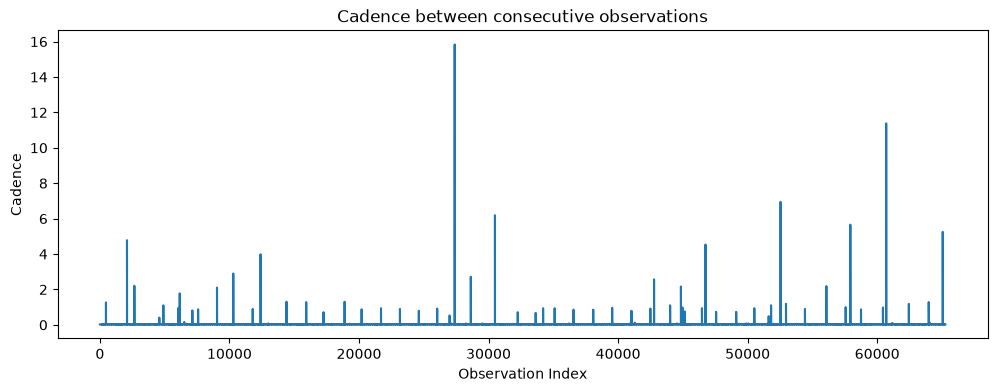

In [23]:
sample = np.load(r"D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset\CONFIRMED\3939150.npz")

time = sample["time"]

dt = np.diff(time)

plt.figure(figsize=(12,4))

plt.plot(dt)

plt.xlabel("Observation Index")

plt.ylabel("Cadence")

plt.title("Cadence between consecutive observations")

plt.show()

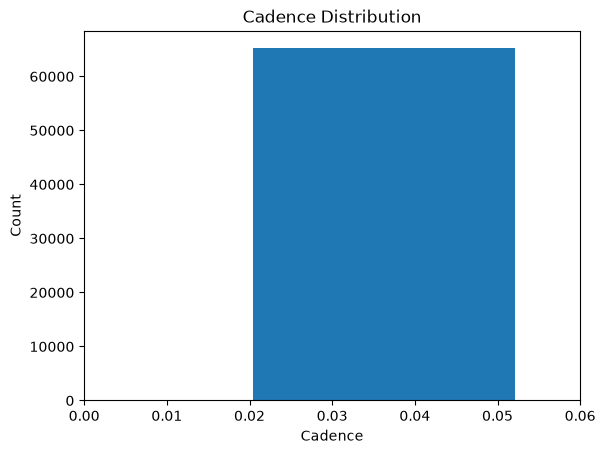

In [ ]:
plt.hist(dt, bins=500)
plt.xlim(0,0.06)

plt.xlabel("Cadence")

plt.ylabel("Count") 

plt.title("Cadence Distribution")

plt.show()

In [25]:
median_dt = np.median(dt)

gap_idx = np.where(dt > 5 * median_dt)[0]

print(f"Found {len(gap_idx)} large gaps")

for idx in gap_idx:
    print(
        f"Gap after sample {idx}: "
        f"{dt[idx]:.4f} days"
    )

Found 62 large gaps
Gap after sample 468: 1.2669 days
Gap after sample 2092: 4.7816 days
Gap after sample 2662: 2.2069 days
Gap after sample 4587: 0.4087 days
Gap after sample 4899: 1.1034 days
Gap after sample 6059: 0.9603 days
Gap after sample 6162: 1.7777 days
Gap after sample 6510: 0.1635 days
Gap after sample 7138: 0.8173 days
Gap after sample 7582: 0.8786 days
Gap after sample 9040: 2.1046 days
Gap after sample 10296: 2.9015 days
Gap after sample 11795: 0.8991 days
Gap after sample 12402: 3.9846 days
Gap after sample 14404: 1.3078 days
Gap after sample 15926: 1.2874 days
Gap after sample 17263: 0.7152 days
Gap after sample 18889: 1.3078 days
Gap after sample 20203: 0.8786 days
Gap after sample 21700: 0.9399 days
Gap after sample 23161: 0.8990 days
Gap after sample 24619: 0.7969 days
Gap after sample 26035: 0.9195 days
Gap after sample 26994: 0.5313 days
Gap after sample 27387: 15.8356 days
Gap after sample 28630: 2.7177 days
Gap after sample 30493: 6.1916 days
Gap after sample 32

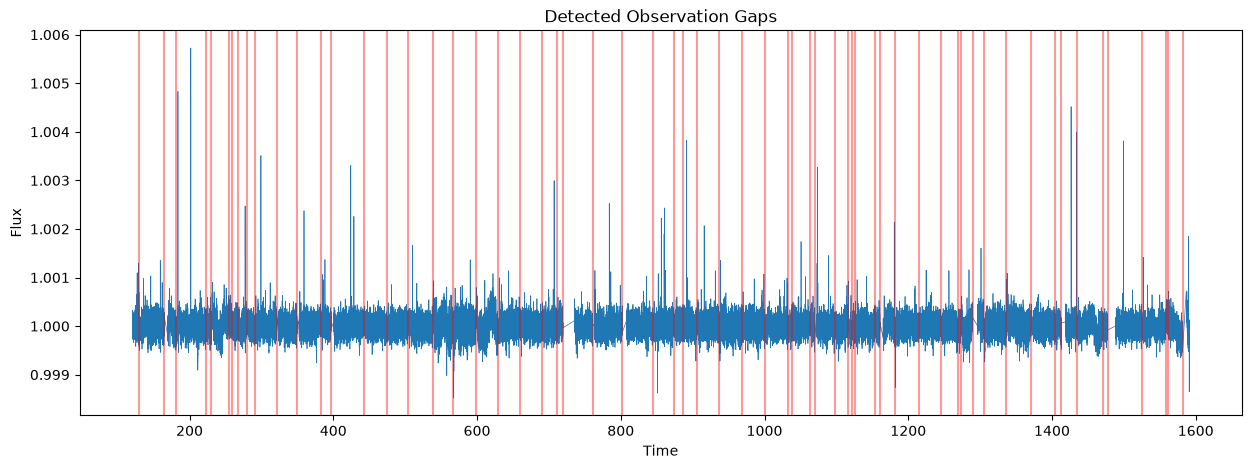

In [26]:
plt.figure(figsize=(15,5))

plt.plot(sample["time"], sample["flux"], lw=0.5)

for idx in gap_idx:
    plt.axvline(sample["time"][idx], color="red", alpha=0.4)

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Detected Observation Gaps")

plt.show()

In [33]:
df.groupby("class")[[
    "length",
    "std_flux",
    "min_flux",
    "max_flux",
    "mean_flux"
]].describe()

length                                                          \
                count          mean           std      min       25%      50%   
class                                                                           
CANDIDATE        53.0  63081.867925   5655.579791  31977.0  64792.00  64794.0   
CONFIRMED        99.0  60397.424242   7937.677129  29957.0  52286.00  64793.0   
FALSE_POSITIVE  104.0  58499.576923  14008.075154   1284.0  59748.75  64793.0   

                                 std_flux            ...  max_flux            \
                    75%      max    count      mean  ...       75%       max   
class                                                ...                       
CANDIDATE       64797.0  65267.0     53.0  0.001411  ...  1.042333  1.087809   
CONFIRMED       64797.0  65266.0     99.0  0.001548  ...  1.034357  1.294856   
FALSE_POSITIVE  64798.0  65268.0    104.0  0.006816  ...  1.044197  1.313390   

               mean_flux                                                    \
                   count      mean       std       min       25%       50%   
class                                                                        
CANDIDATE           53.0  0.999965  0.000123  0.999506  0.999982  1.000002   
CONFIRMED           99.0  0.999943  0.000147  0.999297  0.999969  1.000000   
FALSE_POSITIVE     104.0  0.998815  0.004967  0.953038  0.999903  0.999998   

                                    
                     75%       max  
class                               
CANDIDATE       1.000008  1.000297  
CONFIRMED       1.000005  1.000232  
FALSE_POSITIVE  1.000008  1.000233  

[3 rows x 40 columns]

# level 3

class
FALSE_POSITIVE    104
CONFIRMED          99
CANDIDATE          53
Name: count, dtype: int64


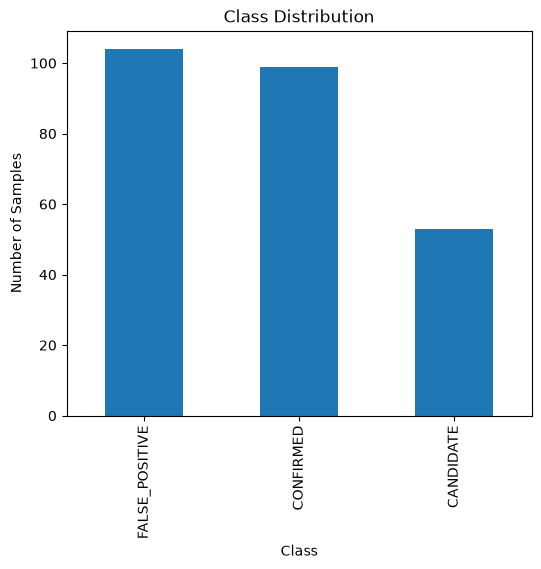

In [34]:
class_counts = df["class"].value_counts()

print(class_counts)

plt.figure(figsize=(6,5))
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

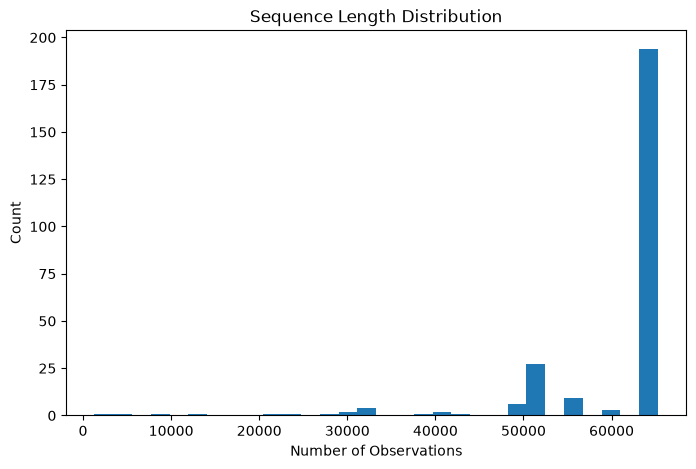

count      256.000000
mean     60182.187500
std      10626.246607
min       1284.000000
25%      63168.750000
50%      64793.000000
75%      64798.000000
max      65268.000000
Name: length, dtype: float64


In [35]:
plt.figure(figsize=(8,5))

plt.hist(df["length"], bins=30)

plt.title("Sequence Length Distribution")
plt.xlabel("Number of Observations")
plt.ylabel("Count")

plt.show()

print(df["length"].describe())

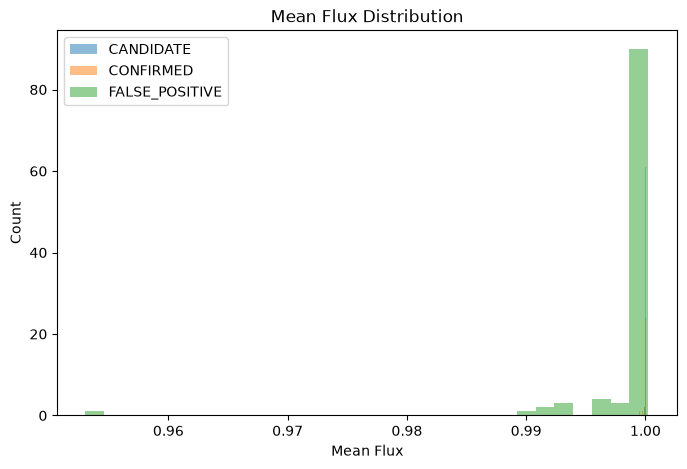

In [37]:
plt.figure(figsize=(8,5))

for cls in df["class"].unique():

    subset = df[df["class"] == cls]

    plt.hist(
        subset["mean_flux"],
        bins=30,
        alpha=0.5,
        label=cls
    )

plt.legend()

plt.title("Mean Flux Distribution")
plt.xlabel("Mean Flux")
plt.ylabel("Count")

plt.show()

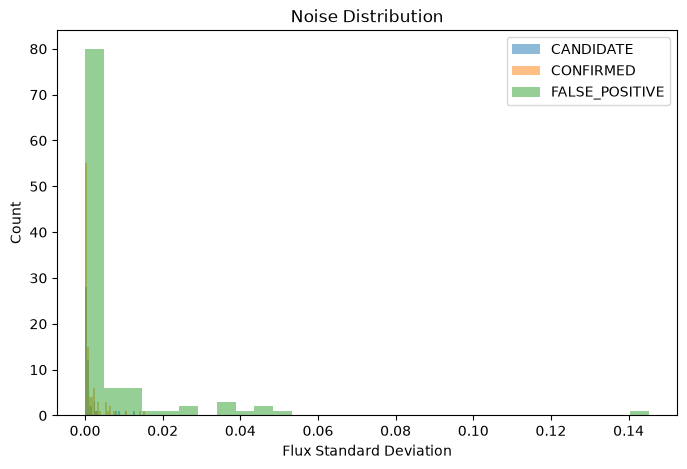

In [38]:
plt.figure(figsize=(8,5))

for cls in df["class"].unique():

    subset = df[df["class"] == cls]

    plt.hist(
        subset["std_flux"],
        bins=30,
        alpha=0.5,
        label=cls
    )

plt.legend()

plt.title("Noise Distribution")
plt.xlabel("Flux Standard Deviation")
plt.ylabel("Count")

plt.show()

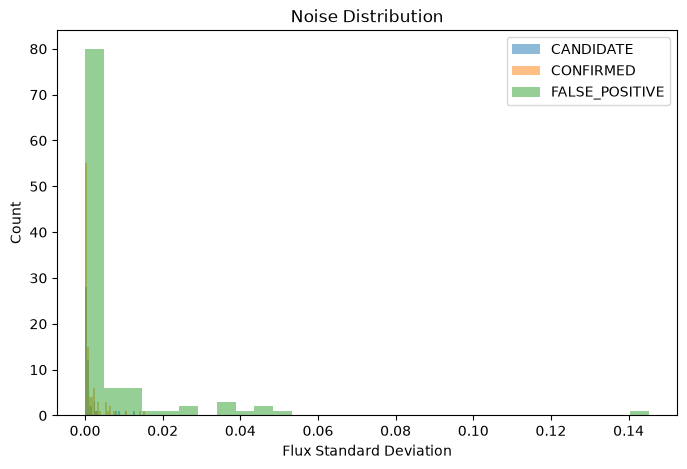

In [ ]:
plt.figure(figsize=(8,5))

for cls in df["class"].unique():

    subset = df[df["class"] == cls]

    plt.hist(
        subset["std_flux"],
        bins=30,
        alpha=0.5,
        label=cls
    )

plt.legend()

plt.title("Noise Distribution")
plt.xlabel("Flux Standard Deviation")
plt.ylabel("Count")

plt.show()

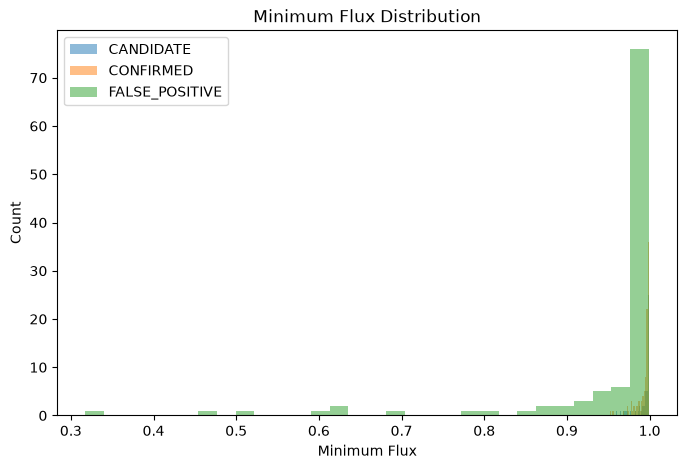

In [39]:
plt.figure(figsize=(8,5))

for cls in df["class"].unique():

    subset = df[df["class"] == cls]

    plt.hist(
        subset["min_flux"],
        bins=30,
        alpha=0.5,
        label=cls
    )

plt.legend()

plt.title("Minimum Flux Distribution")
plt.xlabel("Minimum Flux")
plt.ylabel("Count")

plt.show()

In [40]:
top_noise = df.sort_values(
    by="std_flux",
    ascending=False
).head(10)

print(top_noise[
    [
        "file",
        "class",
        "std_flux",
        "mean_flux"
    ]
])

             file           class  std_flux  mean_flux
178   3440230.npz  FALSE_POSITIVE  0.145253   0.953038
237   8690001.npz  FALSE_POSITIVE  0.050972   0.991080
234   8589754.npz  FALSE_POSITIVE  0.047640   0.990053
231   8572936.npz  FALSE_POSITIVE  0.045139   0.993379
158  10711551.npz  FALSE_POSITIVE  0.041161   0.992580
152  10129482.npz  FALSE_POSITIVE  0.036651   0.991177
211   7133286.npz  FALSE_POSITIVE  0.035298   0.998668
177   3323289.npz  FALSE_POSITIVE  0.034251   0.996224
184   4372765.npz  FALSE_POSITIVE  0.026076   0.995981
183   4365461.npz  FALSE_POSITIVE  0.024339   0.992684


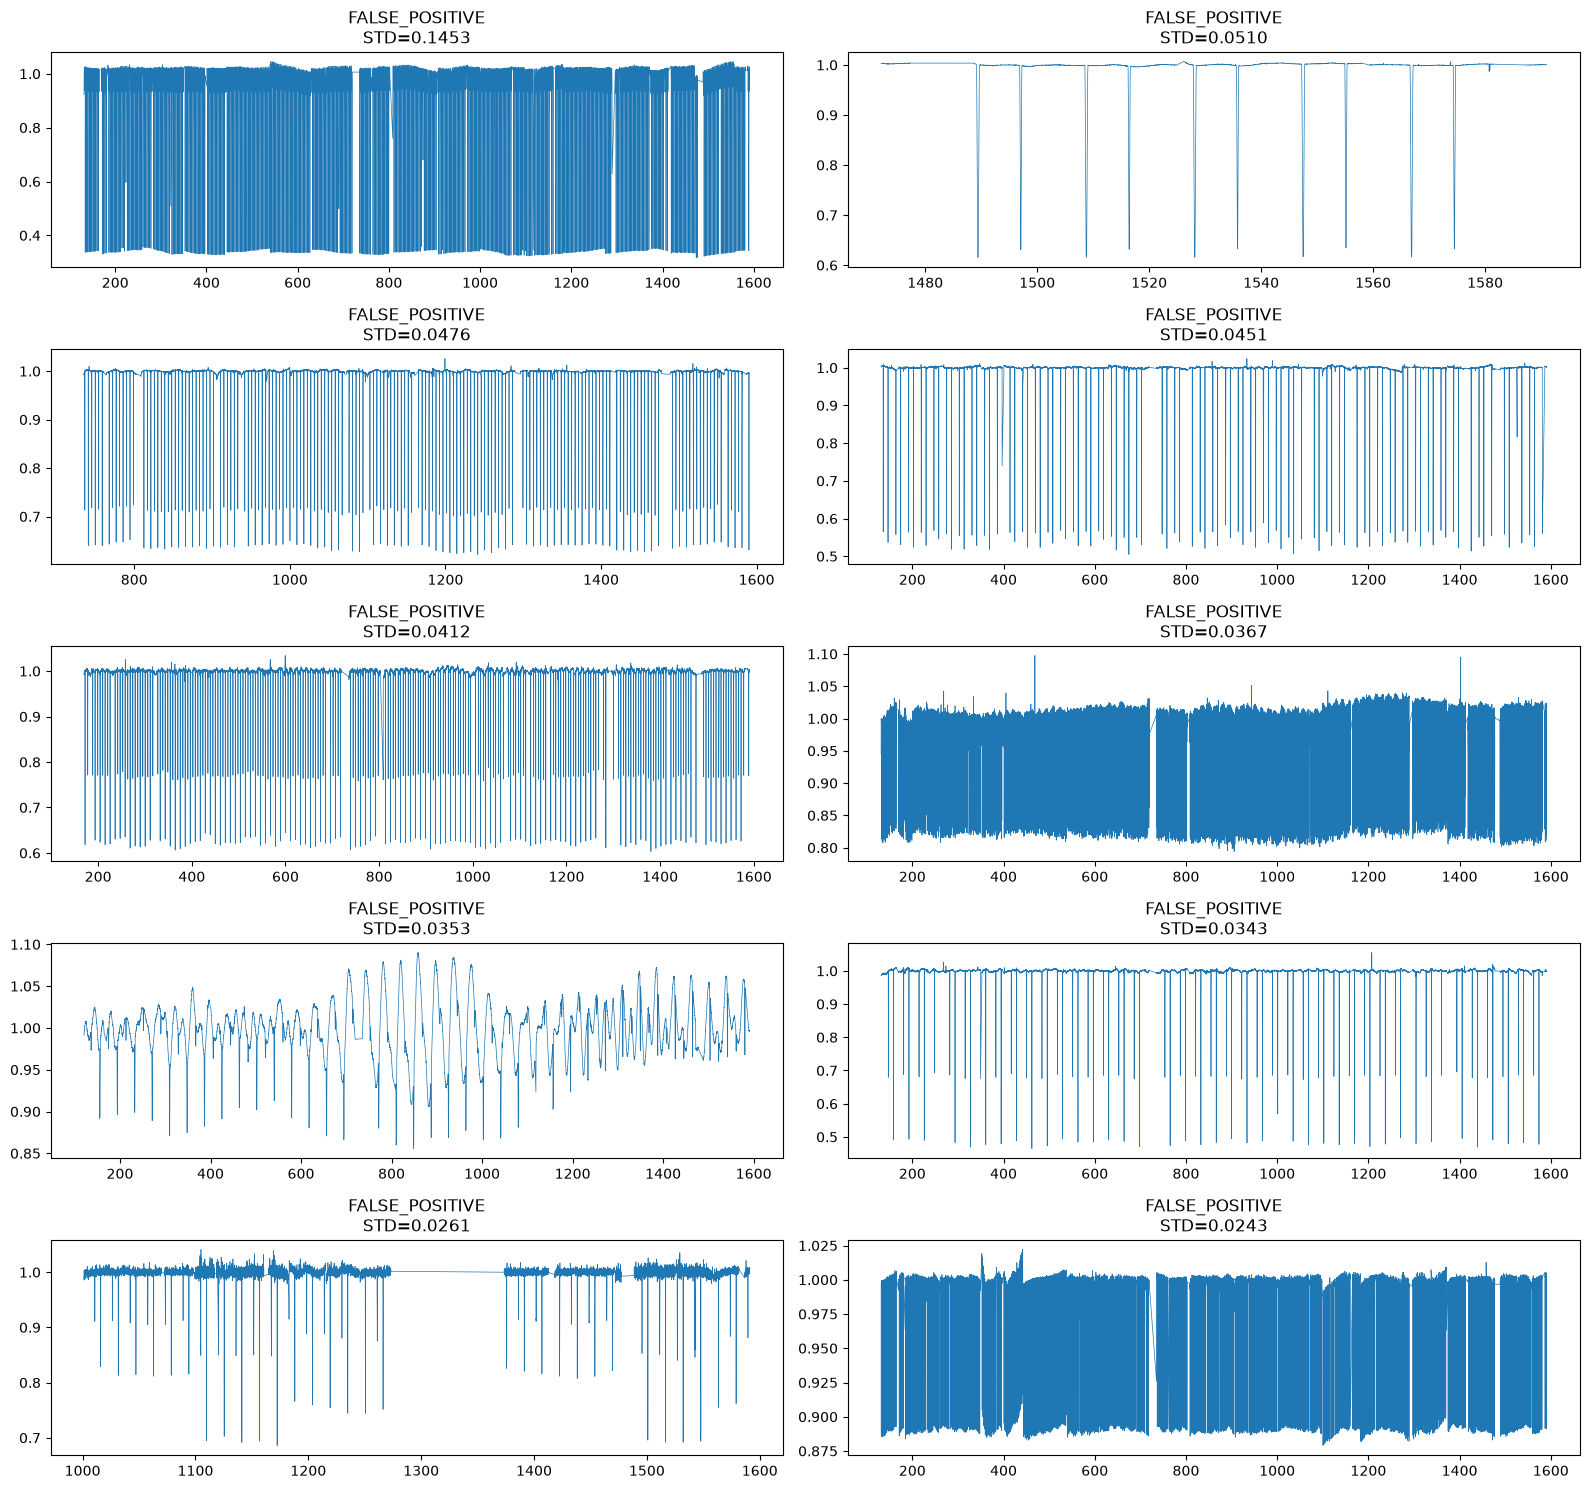

In [42]:
DATASET_DIR = r"D:\Kush\2nd Year\Hackathons\hacktoskill_exoplanet\dataset"

fig, axes = plt.subplots(5,2, figsize=(16,15))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top_noise.iterrows()):

    path = os.path.join(
        DATASET_DIR,
        row["class"],
        row["file"]
    )

    data = np.load(path)

    ax.plot(
        data["time"],
        data["flux"],
        linewidth=0.5
    )

    ax.set_title(
        f'{row["class"]}\nSTD={row["std_flux"]:.4f}'
    )

plt.tight_layout()
plt.show()

In [43]:
deepest = df.sort_values(
    by="min_flux"
).head(10)

print(deepest[
    [
        "file",
        "class",
        "min_flux"
    ]
])

             file           class  min_flux
178   3440230.npz  FALSE_POSITIVE  0.317551
177   3323289.npz  FALSE_POSITIVE  0.464794
231   8572936.npz  FALSE_POSITIVE  0.504517
158  10711551.npz  FALSE_POSITIVE  0.603011
237   8690001.npz  FALSE_POSITIVE  0.615118
234   8589754.npz  FALSE_POSITIVE  0.621445
184   4372765.npz  FALSE_POSITIVE  0.685915
152  10129482.npz  FALSE_POSITIVE  0.793920
214   7605600.npz  FALSE_POSITIVE  0.799119
211   7133286.npz  FALSE_POSITIVE  0.855657


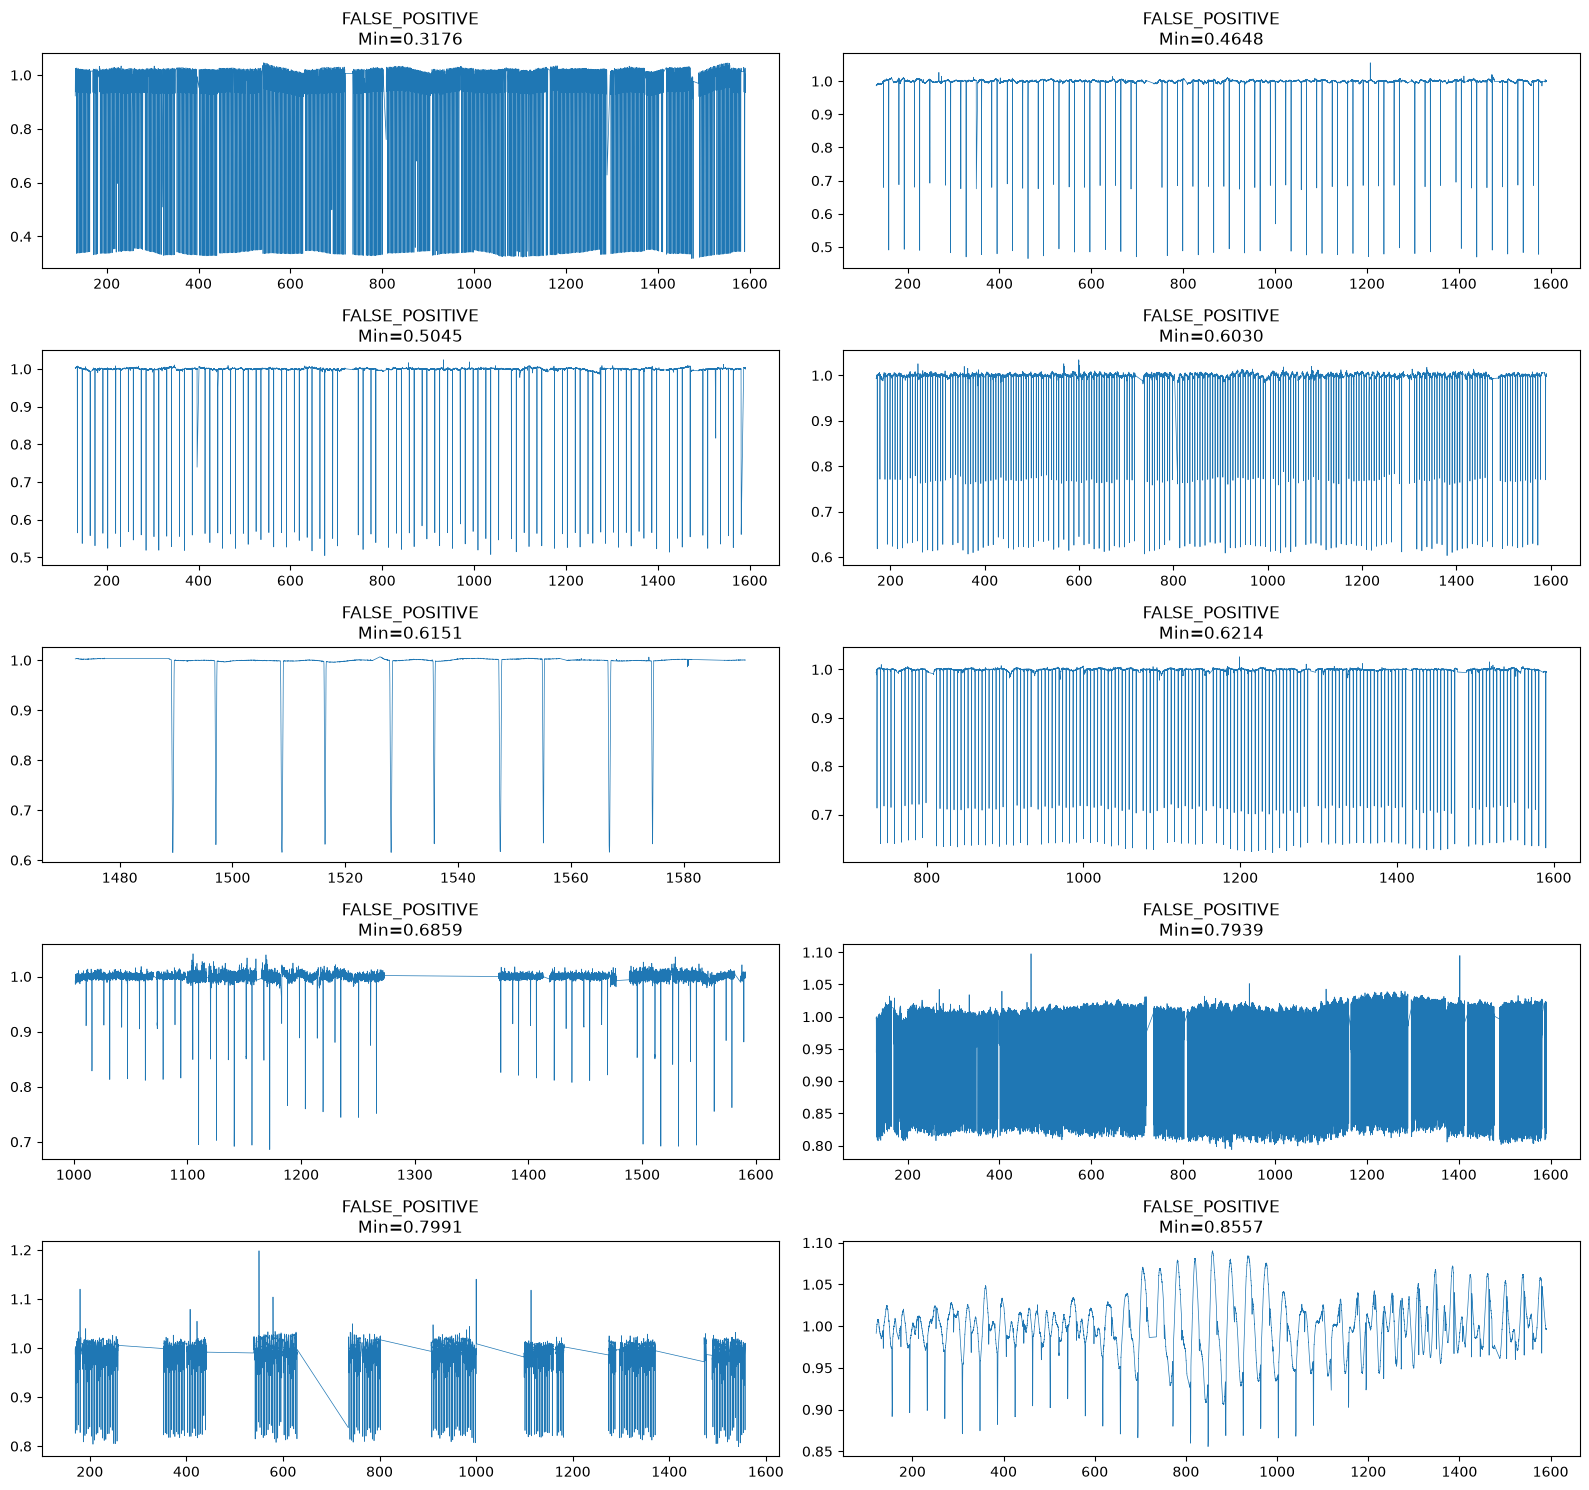

In [ ]:
fig, axes = plt.subplots(5,2, figsize=(16,15))
axes = axes.flatten()

for ax, (_, row) in zip(axes, deepest.iterrows()):

    path = os.path.join(
        DATASET_DIR,
        row["class"],
        row["file"] 
    )

    data = np.load(path)

    ax.plot(
        data["time"],
        data["flux"],
        linewidth=0.5
    )

    ax.set_title(
        f'{row["class"]}\nMin={row["min_flux"]:.4f}'
    )

plt.tight_layout()
plt.show()

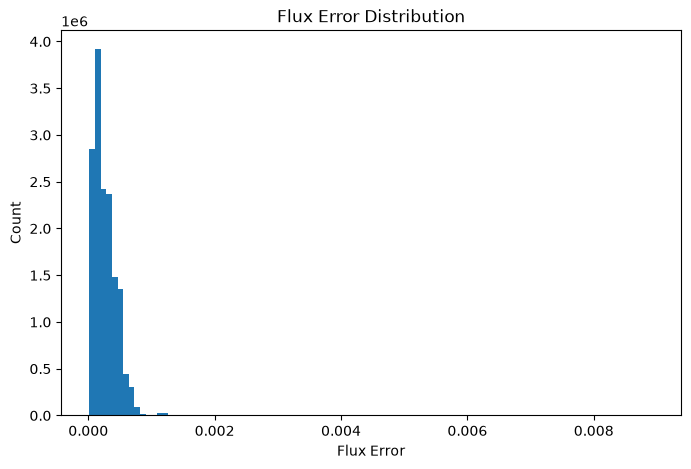

In [45]:
flux_error = []

for _, row in df.iterrows():

    path = os.path.join(
        DATASET_DIR,
        row["class"],
        row["file"]
    )

    data = np.load(path)

    flux_error.extend(data["flux_err"])

flux_error = np.array(flux_error)

plt.figure(figsize=(8,5))

plt.hist(flux_error, bins=100)

plt.title("Flux Error Distribution")
plt.xlabel("Flux Error")
plt.ylabel("Count")

plt.show()

Correlation = 0.0023576472311316703


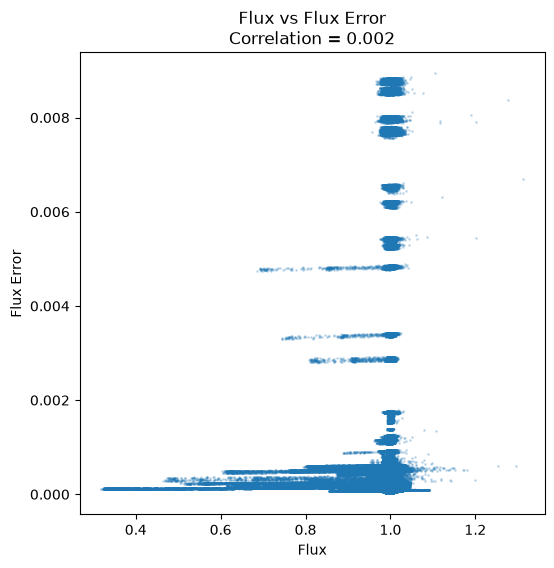

In [46]:
flux = []
flux_err = []

for _, row in df.iterrows():

    path = os.path.join(
        DATASET_DIR,
        row["class"],
        row["file"]
    )

    data = np.load(path)

    flux.extend(data["flux"])
    flux_err.extend(data["flux_err"])

flux = np.array(flux)
flux_err = np.array(flux_err)

corr = np.corrcoef(
    flux,
    flux_err
)[0,1]

print("Correlation =", corr)

plt.figure(figsize=(6,6))

plt.scatter(
    flux,
    flux_err,
    s=1,
    alpha=0.2
)

plt.xlabel("Flux")
plt.ylabel("Flux Error")

plt.title(
    f"Flux vs Flux Error\nCorrelation = {corr:.3f}"
)

plt.show()

In [47]:
total = len(df)

print("Files:", total)

print()

print("NaN Time")

print(df["nan_time"].gt(0).sum())

print()

print("NaN Flux")

print(df["nan_flux"].gt(0).sum())

print()

print("NaN Flux Error")

print(df["nan_flux_err"].gt(0).sum())

print()

print("Infinite Flux")

print(df["inf_flux"].gt(0).sum())

print()

print("Duplicate Timestamps")

print(df["duplicate_time"].gt(0).sum())

Files: 256

NaN Time
0

NaN Flux
0

NaN Flux Error
0

Infinite Flux
0

Duplicate Timestamps
0


NaN Flux          0.0
NaN Flux Error    0.0
Infinite Flux     0.0
Duplicate Time    0.0
dtype: float64


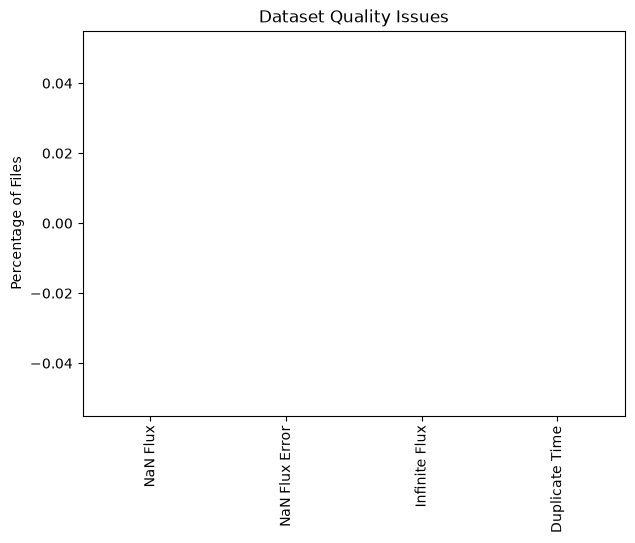

In [48]:
issues = pd.DataFrame({

    "NaN Flux":
        df["nan_flux"] > 0,

    "NaN Flux Error":
        df["nan_flux_err"] > 0,

    "Infinite Flux":
        df["inf_flux"] > 0,

    "Duplicate Time":
        df["duplicate_time"] > 0

})

percent = issues.mean() * 100

print(percent)

plt.figure(figsize=(7,5))

percent.plot(kind="bar")

plt.ylabel("Percentage of Files")

plt.title("Dataset Quality Issues")

plt.show()